Method used to cluster the households:
1. Reduce the dimension of each household from 18960 to a lower dimension. A standard method is the Piecewise Aggregation Approximation (PAA), which takes the average over fixed-sized windows and uses the averages to represent the high-dimensional data.
2. Run the K-Menas algorithm on the reduced dimensional data, which finds k centroids.
3. Find k households that align closely with the found k centroids to serve as the representative households.

    

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

!pip install pyts
from  pyts.approximation  import PiecewiseAggregateApproximation
from sklearn.cluster import KMeans




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.2 MB/s eta 0:00:00


In [3]:
# please download the uk_data_clean.zip file and change this line to your local directory
df = pd.read_csv('/content/drive/My Drive/household_energy_consump/uk_data_clean.csv')
pivoted = df.pivot(index='datetime', columns='id', values='target')
def dtarg(x):
  return(pd.to_datetime(x,format='%Y-%m-%d %H:%M:%S'))
pivoted.index = pivoted.index.map(dtarg)
np.random.seed(216) # This is to make a consistent train-test household split
testcols = np.random.choice(pivoted.columns, size=int((len(pivoted.columns)*.2)//1), replace=False, p=None)
traincols = [x for x in pivoted.columns if x not in testcols]
energy = pivoted[traincols]
energy_testing_set = pivoted[testcols]

In [4]:
input_window = 7 * 48       # 336
forecast_horizon = 1 * 48   # 48

total_samples = len(energy) - input_window - forecast_horizon

# Create raw data splits before scaling
split1 = int(0.7 * total_samples)
split2 = int(0.85 * total_samples)



train_end = split1 + input_window + forecast_horizon
val_end = split2 + input_window + forecast_horizon

# To cluster households, we should only use their data in the training set, so not to leak info
energy_np = energy.values
train_energy_raw = energy_np[:train_end]





In [5]:
# PAA transformation
ii = 0 # number of times to run KMeans
household_idx = []
while ii < 10:

  window_size =48
  paa = PiecewiseAggregateApproximation(window_size=window_size)
  energy_paa = paa.transform(train_energy_raw.T) # energy_paa is a np array of dimension (736, 279). Each row is a household and each column is the average over the 48 values for a day

  # run k-mean on energy_paa
  k=5
  kmeans_paa = KMeans(n_clusters=k)
  kmeans_paa.fit(energy_paa)
  centroids_paa = kmeans_paa.cluster_centers_

  date_list = list(dict.fromkeys([d.date() for d in energy.index]))
  # date_list = list(energy.index.date[0:279])

  # Find the k real samples that are the closest to the found centroids
  # this is neccessary because after paa we don't have the 30-min granulated data anymore and we need to find the real samples to recover the granulated data
  from sklearn.metrics import pairwise_distances_argmin_min

  closest_indices_paa, distances_paa = pairwise_distances_argmin_min(centroids_paa, energy_paa)

  # Extract the actual samples
  representative_samples_paa = energy_paa[closest_indices_paa]  # shape: (10, 300)
  representative_samples = energy.iloc[:,closest_indices_paa]   # shape = (10, 18960)

  household_idx.append(closest_indices_paa)

  ii = ii+1

flat_household_idx = np.concatenate(household_idx)

# Get top k most common elements
top = pd.Series(flat_household_idx).value_counts().head(k).index.tolist()
print(top)
print("household id: ", energy.iloc[:,top])

[50, 246, 710, 586, 495]
household id:  id                   uk_MAC000507  uk_MAC002086  uk_MAC005385  uk_MAC004809  \
datetime                                                                      
2012-11-01 00:00:00         0.229         0.083         0.118         0.123   
2012-11-01 00:30:00         0.270         0.057         3.898         0.125   
2012-11-01 01:00:00         0.266         0.082         3.856         0.128   
2012-11-01 01:30:00         0.256         0.074         3.189         0.162   
2012-11-01 02:00:00         0.075         0.049         2.555         0.166   
...                           ...           ...           ...           ...   
2013-11-30 21:30:00         0.236         0.158         0.152         0.390   
2013-11-30 22:00:00         0.260         0.112         0.163         0.434   
2013-11-30 22:30:00         0.256         0.116         0.190         0.485   
2013-11-30 23:00:00         0.438         0.119         0.154         0.475   
2013-11-30 2

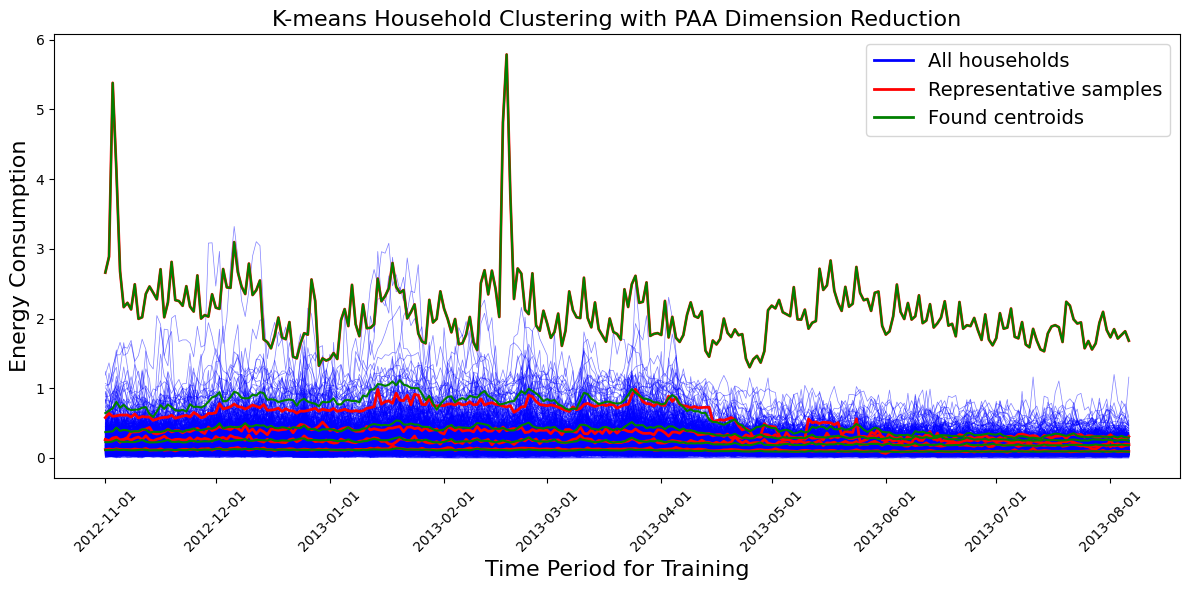

In [6]:

# plot the result of paa + kmeans
from matplotlib.lines import Line2D
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))

# date_list = range(energy_paa.shape[1])
date_list = energy.index.date[0:279*48:48]

# Plot all 736 households in blue
for series in energy_paa:
    plt.plot(date_list,series, color='blue', alpha=0.5, linewidth=0.5)


# Plot all k representative_samples in red
for center in representative_samples_paa:
    plt.plot(date_list, center, color='red', linewidth=2)

# Plot all k centroids in green
for center in centroids_paa:
    plt.plot(date_list, center, color='green', linewidth=1.5)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


plt.title("K-means Household Clustering with PAA Dimension Reduction", fontsize =16)
plt.xlabel("Time Period for Training",fontsize =16)
plt.ylabel("Energy Consumption", fontsize =16)
# Create custom legend
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='All households'),
    Line2D([0], [0], color='red', lw=2, label='Representative samples'),
    Line2D([0], [0], color='green', lw=2, label='Found centroids')
]
plt.legend(handles=legend_elements,fontsize=14)

# plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
